# 04 全量 T5 训练与报告更新

本节在完整训练集上训练 Mengzi-T5-Base，此处的“完整训练”指使用完整训练集训练 1 个 epoch。训练完成后保存全部结果，并调用报告生成脚本，将报告中的指标更新为全量训练结果。

## 0. 实验设定

- 数据：项目目录下的公开中文问答数据集；
- 训练集：全部非空答案训练样本；
- 验证集：过滤空答案样本后完整评估；
- 训练轮数：1 epoch；
- 设备：优先使用 Apple MPS，无 MPS 时退回 CPU；
- 输出：`outputs/t5_full_mps/`，与 `outputs/t5_cpu_safe/` 相互独立。

In [1]:
# ⚠️ 必须在 import torch 之前设置：解除 MPS 显存上限。
# 本机 PyTorch 实际只用约 4GB，但 MPS 碎片累积会撞上 ~30GB 的安全阀导致 OOM。
# 设为 "0.0" 表示不设上限，交给 macOS 统一内存自行管理。
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

from pathlib import Path
import json
import math
import random
import subprocess
import sys
from inspect import signature

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("torch:", torch.__version__)
print("mps available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)
print("MPS watermark ratio:", os.environ.get("PYTORCH_MPS_HIGH_WATERMARK_RATIO"))

torch: 2.11.0
mps available: True
MPS watermark ratio: 0.0


## 1. 实验配置

使用完整训练集（不再抽取 1024 条样本）。`GRADIENT_ACCUMULATION_STEPS=4` 表示每 4 个样本累积一次梯度更新，可稳定训练，且不减少模型看过的训练样本总量。

MPS 训练时显存较紧张，采用内存安全配置：`MAX_INPUT_LENGTH=384`，并开启 gradient checkpointing，对超长 context 截断更保守。

In [2]:
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "DuReaderQG"
MODEL_NAME_OR_PATH = PROJECT_DIR / "models" / "mengzi-t5-base"

RUN_NAME = "full_mps" if torch.backends.mps.is_available() else "full_cpu"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "t5_full_mps"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"
FIGURE_DIR = PROJECT_DIR / "figures"

MAX_INPUT_LENGTH = 384
MAX_TARGET_LENGTH = 32
NUM_TRAIN_EPOCHS = 1
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 5e-5
LOGGING_STEPS = 50
EVAL_STEPS = 250
SAVE_STEPS = 250
SEED = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

config_summary = {
    "run_mode": RUN_NAME,
    "data_dir": str(DATA_DIR),
    "model_name_or_path": str(MODEL_NAME_OR_PATH),
    "max_input_length": MAX_INPUT_LENGTH,
    "memory_safe_notes": "MPS run uses max_input_length=384 and gradient checkpointing to avoid out-of-memory",
    "max_target_length": MAX_TARGET_LENGTH,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
}
config_summary

{'run_mode': 'full_mps',
 'data_dir': '/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/data/DuReaderQG',
 'model_name_or_path': '/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/models/mengzi-t5-base',
 'max_input_length': 384,
 'memory_safe_notes': 'MPS run uses max_input_length=384 and gradient checkpointing to avoid out-of-memory',
 'max_target_length': 32,
 'num_train_epochs': 1,
 'train_batch_size': 1,
 'eval_batch_size': 2,
 'gradient_accumulation_steps': 4,
 'learning_rate': 5e-05,
 'seed': 42}

## 2. 读取完整数据

验证集中的空答案样本仍然过滤掉，因为 BLEU 需要参考答案。

In [3]:
def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def valid_answer(row):
    return str(row.get("answer", "")).strip() != ""

train_all = read_jsonl(DATA_DIR / "train.json")
dev_all = read_jsonl(DATA_DIR / "dev.json")

train_rows = [row for row in train_all if valid_answer(row)]
dev_rows = [row for row in dev_all if valid_answer(row)]

random.seed(SEED)
random.shuffle(train_rows)

config_summary.update({
    "train_total_rows": len(train_all),
    "dev_total_rows": len(dev_all),
    "train_sample_size": len(train_rows),
    "dev_sample_size": len(dev_rows),
})

print("train:", len(train_rows), "/", len(train_all))
print("dev:", len(dev_rows), "/", len(dev_all))
print("estimated optimizer steps:", math.ceil(len(train_rows) / (TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)) * NUM_TRAIN_EPOCHS)

train: 14520 / 14520
dev: 983 / 984
estimated optimizer steps: 3630


## 3. 加载本地 Mengzi-T5 模型

In [4]:
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH, use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME_OR_PATH)
model.config.use_cache = False
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
print("vocab size:", len(tokenizer))
print("gradient checkpointing:", getattr(model, "is_gradient_checkpointing", False))

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


vocab size: 32128
gradient checkpointing: True


## 4. Dataset 构造

In [5]:
def build_model_input(row):
    return f"question: {row['question']} context: {row['context']}"


class QADataset(Dataset):
    def __init__(self, rows, tokenizer, max_input_length=512, max_target_length=32):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        model_input = build_model_input(row)
        target = str(row["answer"])
        item = self.tokenizer(model_input, max_length=self.max_input_length, truncation=True)
        labels = self.tokenizer(text_target=target, max_length=self.max_target_length, truncation=True)
        item["labels"] = labels["input_ids"]
        return item


train_dataset = QADataset(train_rows, tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)
dev_dataset = QADataset(dev_rows, tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)

train_dataset[0].keys()

KeysView({'input_ids': [7, 3454, 2055, 21293, 15807, 13, 7, 55, 11969, 63, 14978, 1311, 1548, 7, 25395, 7368, 1733, 1550, 13, 7, 1548, 1513, 2130, 94, 6, 14978, 11969, 40, 3, 135, 5084, 2010, 384, 21, 1758, 5, 14890, 275, 3, 397, 28530, 6530, 3, 4703, 259, 28529, 4304, 3686, 6, 55, 16749, 856, 14978, 55, 14890, 275, 3, 14978, 37, 14890, 275, 241, 11415, 3, 1010, 384, 20, 5637, 14890, 14978, 521, 4294, 6, 4495, 4703, 1188, 7786, 856, 1956, 3498, 165, 92, 22, 3391, 165, 92, 25, 1548, 1513, 26, 138, 6, 1821, 11969, 22, 1537, 6205, 25, 3498, 78, 14978, 100, 92, 16749, 26, 108, 6, 55, 16749, 3498, 78, 14978, 165, 232, 11969, 22, 1537, 6205, 4547, 173, 6, 55, 1548, 24747, 497, 1513, 5349, 856, 1463, 55, 26, 219, 6, 11969, 5172, 5798, 295, 1387, 22, 19062, 6, 19628, 10139, 25, 3, 594, 8, 627, 4531, 16449, 26337, 3, 1205, 14978, 1548, 1513, 4, 1935, 13, 1605, 14978, 529, 3, 206, 16749, 604, 14978, 342, 6530, 5, 11969, 742, 6205, 3, 388, 5408, 659, 4, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1,

## 5. BLEU 评价函数

采用与训练流程一致的字符级 BLEU。为兼容不同 Transformers 版本和 MPS 输出，先清理非法 token id，再解码。

In [6]:
def char_tokens(text):
    return list(str(text).strip())


def modified_precision(pred_tokens, ref_tokens, n):
    if len(pred_tokens) < n:
        return 0.0
    pred_ngrams = {}
    ref_ngrams = {}
    for i in range(len(pred_tokens) - n + 1):
        gram = tuple(pred_tokens[i:i+n])
        pred_ngrams[gram] = pred_ngrams.get(gram, 0) + 1
    for i in range(len(ref_tokens) - n + 1):
        gram = tuple(ref_tokens[i:i+n])
        ref_ngrams[gram] = ref_ngrams.get(gram, 0) + 1
    overlap = sum(min(count, ref_ngrams.get(gram, 0)) for gram, count in pred_ngrams.items())
    total = max(1, sum(pred_ngrams.values()))
    return overlap / total


def sentence_bleu(prediction, reference, max_n=4, smooth=1e-9):
    pred_tokens = char_tokens(prediction)
    ref_tokens = char_tokens(reference)
    if not pred_tokens or not ref_tokens:
        return 0.0
    bp = 1.0 if len(pred_tokens) > len(ref_tokens) else math.exp(1 - len(ref_tokens) / max(1, len(pred_tokens)))
    precisions = [max(modified_precision(pred_tokens, ref_tokens, n), smooth) for n in range(1, max_n + 1)]
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n)


def corpus_bleu(predictions, references, max_n=4):
    scores = [sentence_bleu(pred, ref, max_n=max_n) for pred, ref in zip(predictions, references)]
    return float(np.mean(scores)) if scores else 0.0


def bleu_scores(predictions, references):
    return {f"bleu_{n}": corpus_bleu(predictions, references, max_n=n) for n in range(1, 5)}


def sanitize_token_ids(array, pad_token_id):
    arr = np.asarray(array)
    vocab_size = len(tokenizer)
    arr = np.where(arr == -100, pad_token_id, arr)
    arr = np.where((arr < 0) | (arr >= vocab_size), pad_token_id, arr)
    return arr.astype(np.int64)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    pad_token_id = tokenizer.pad_token_id or 0
    predictions = sanitize_token_ids(predictions, pad_token_id)
    labels = sanitize_token_ids(labels, pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    scores = bleu_scores(decoded_preds, decoded_labels)
    scores["prediction_avg_len"] = float(np.mean([len(str(x)) for x in decoded_preds])) if decoded_preds else 0.0
    return scores

## 6. 配置 Trainer

这里支持断点续训：如果 `outputs/t5_full_mps/checkpoints` 里已有 checkpoint，下一节训练会自动从最近的 checkpoint 接着跑。

In [7]:
arg_params = signature(Seq2SeqTrainingArguments.__init__).parameters
strategy_key = "eval_strategy" if "eval_strategy" in arg_params else "evaluation_strategy"

training_args_kwargs = {
    "output_dir": str(CHECKPOINT_DIR),
    strategy_key: "steps",
    "eval_steps": EVAL_STEPS,
    "logging_steps": LOGGING_STEPS,
    "save_strategy": "steps",
    "save_steps": SAVE_STEPS,
    "save_total_limit": 3,
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    # 训练中途的验证只算 eval_loss，不做 generate，避免 MPS 显存峰值导致 OOM。
    # 最优模型按 eval_loss 选取；最终 BLEU 在第 10/11 小节单独计算，不受影响。
    "predict_with_generate": False,
    "report_to": [],
    "seed": SEED,
    "remove_unused_columns": True,
}

optional_args = {
    "dataloader_num_workers": 0,
    "dataloader_pin_memory": False,
    "gradient_checkpointing": True,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    # 验证时只回传 loss，跳过预测结果收集与 compute_metrics，进一步省显存
    "prediction_loss_only": True,
    # 每 50 步清一次 MPS 显存缓存
    "torch_empty_cache_steps": 50,
}
for key, value in optional_args.items():
    if key in arg_params:
        training_args_kwargs[key] = value

training_args = Seq2SeqTrainingArguments(**training_args_kwargs)

trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": dev_dataset,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
}

trainer_params = signature(Seq2SeqTrainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Seq2SeqTrainer(**trainer_kwargs)

last_checkpoint = get_last_checkpoint(str(CHECKPOINT_DIR)) if CHECKPOINT_DIR.exists() else None
print("device:", training_args.device)
print("last checkpoint:", last_checkpoint)
training_args

device: mps
last checkpoint: /Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/outputs/t5_full_mps/checkpoints/checkpoint-750


Seq2SeqTrainingArguments(output_dir='/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/outputs/t5_full_mps/checkpoints', per_device_train_batch_size=1, num_train_epochs=1, max_steps=-1, learning_rate=5e-05, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs=None, warmup_steps=0, optim=<OptimizerNames.ADAMW_TORCH_FUSED: 'adamw_torch_fused'>, optim_args=None, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, optim_target_modules=None, gradient_accumulation_steps=4, average_tokens_across_devices=True, max_grad_norm=1.0, label_smoothing_factor=0.0, bf16=False, fp16=False, bf16_full_eval=False, fp16_full_eval=False, tf32=None, gradient_checkpointing=True, gradient_checkpointing_kwargs=None, torch_compile=False, torch_compile_backend=None, torch_compile_mode=None, use_liger_kernel=False, liger_kernel_config=None, use_cache=False, neftune_noise_alpha=None, torch_empty_cache_steps=50, auto_find_batch_size=False, logging_strategy=<IntervalStrategy

## 7. 开始全量训练

该步骤耗时较长。若训练中断，重新运行至本单元会自动从最近的 checkpoint 续训。若此前发生 MPS out of memory，建议先执行 `Kernel -> Restart Kernel` 释放残留显存，再从第 1 个单元重新运行至此。

In [8]:
train_result = trainer.train(resume_from_checkpoint=last_checkpoint)
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

train_metrics = train_result.metrics
train_metrics_path = OUTPUT_DIR / "train_metrics.json"
train_metrics_path.write_text(json.dumps(train_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
train_metrics

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Step,Training Loss,Validation Loss
1000,3.188077,0.950580
1250,2.956647,0.938869
1500,2.890396,0.979934
1750,2.817782,0.927427
2000,2.659880,0.872970
2250,2.566488,0.941600
2500,2.539856,0.921764
2750,2.529192,0.878856
3000,2.165482,0.913086
3250,2.250644,0.847276


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 2131.4334,
 'train_samples_per_second': 6.812,
 'train_steps_per_second': 1.703,
 'total_flos': 3685035066365952.0,
 'train_loss': 2.0197126561945136,
 'epoch': 1.0}

## 8. 保存训练日志与 loss 曲线

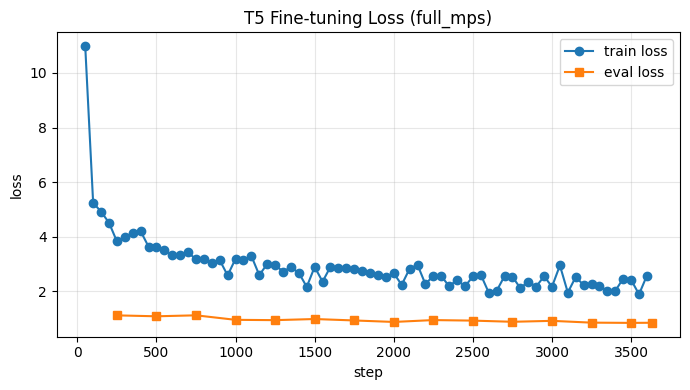

(PosixPath('/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/outputs/t5_full_mps/trainer_log_history.json'),
 PosixPath('/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/figures/t5_full_mps_loss.png'))

In [9]:
log_history = trainer.state.log_history
log_path = OUTPUT_DIR / "trainer_log_history.json"
log_path.write_text(json.dumps(log_history, ensure_ascii=False, indent=2), encoding="utf-8")

train_loss = [(item["step"], item["loss"]) for item in log_history if "loss" in item]
eval_loss = [(item["step"], item["eval_loss"]) for item in log_history if "eval_loss" in item]

plt.figure(figsize=(7, 4))
if train_loss:
    plt.plot([x for x, _ in train_loss], [y for _, y in train_loss], marker="o", label="train loss")
if eval_loss:
    plt.plot([x for x, _ in eval_loss], [y for _, y in eval_loss], marker="s", label="eval loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("T5 Fine-tuning Loss (full_mps)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
loss_figure_path = FIGURE_DIR / "t5_full_mps_loss.png"
plt.savefig(loss_figure_path, dpi=200)
plt.show()

log_path, loss_figure_path

## 9. 完整验证集评估

In [10]:
eval_metrics = trainer.evaluate()
metrics_path = OUTPUT_DIR / "eval_metrics.json"
metrics_path.write_text(json.dumps(eval_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
eval_metrics

Training Loss,Validation Loss,Step
2.574722,0.838489,3630


{'eval_loss': 0.8384885787963867}

## 10. 导出预测样例

In [11]:
def generate_answers(rows, batch_size=EVAL_BATCH_SIZE, max_new_tokens=MAX_TARGET_LENGTH):
    model.eval()
    model_device = next(model.parameters()).device
    predictions = []
    for start in range(0, len(rows), batch_size):
        batch_rows = rows[start:start + batch_size]
        inputs = tokenizer(
            [build_model_input(row) for row in batch_rows],
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            padding=True,
            return_tensors="pt",
        )
        inputs = {key: value.to(model_device) for key, value in inputs.items()}
        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=4)
        predictions.extend(tokenizer.batch_decode(output_ids, skip_special_tokens=True))
    return predictions


prediction_rows = dev_rows[:min(100, len(dev_rows))]
predictions = generate_answers(prediction_rows)
references = [row["answer"] for row in prediction_rows]
prediction_scores = bleu_scores(predictions, references)

prediction_df = pd.DataFrame({
    "id": [row.get("id") for row in prediction_rows],
    "question": [row["question"] for row in prediction_rows],
    "reference": references,
    "prediction": predictions,
    "context": [row["context"] for row in prediction_rows],
})

prediction_csv_path = OUTPUT_DIR / "prediction_samples.csv"
prediction_jsonl_path = OUTPUT_DIR / "prediction_samples.jsonl"
prediction_df.to_csv(prediction_csv_path, index=False, encoding="utf-8-sig")
with prediction_jsonl_path.open("w", encoding="utf-8") as f:
    for item in prediction_df.to_dict(orient="records"):
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(prediction_scores)
prediction_df.head(10)

{'bleu_1': 0.6838588279389465, 'bleu_2': 0.6387110894753043, 'bleu_3': 0.5237661594155039, 'bleu_4': 0.4576449732144681}


,id,question,reference,prediction,context
0,0,2017年银行贷款基准利率,年基准利率4.35%,4.35%,"年基准利率4.35%。 从实际看,贷款的基本条件是: 一是中国大陆居民,年龄在60岁以下; ..."
1,1,2017年银行贷款基准利率,4.35%,4.35%,"年基准利率4.35%。 从实际看,贷款的基本条件是: 一是中国大陆居民,年龄在60岁以下; ..."
2,2,格力空调哪个系列好,U系列,U系列,U系列是最好的，采用国际顶尖技术（由格力自主研发）双级变频压缩机，提高压缩机运转效率，制冷制...
3,3,橱柜宽度,以40至60厘米为宜,550--600MM,平面操作区域进深（即宽度）以40至60厘米为宜；要充分考虑洗菜盆的宽度。以标准洗菜盆来算，应...
4,4,橱柜宽度,40至60厘米,550--600MM,平面操作区域进深（即宽度）以40至60厘米为宜；要充分考虑洗菜盆的宽度。以标准洗菜盆来算，应...
5,5,广州英语培训哪家好,广州东方英文书院,广州东方英文书院,"广州学英语,我认为一定要找对学校,否则花了钱还浪费了时间。广州的英语培训学校,大多是夜校性质..."
6,6,公元前简写,B.C.E.,B.C.,公元常以 A.D.（拉丁文Anno Domini 的缩写，意为“主的生年”）表示，公元前则以...
7,7,公元前简写,B.C.,B.C.,公元常以 A.D.（拉丁文Anno Domini 的缩写，意为“主的生年”）表示，公元前则以...
8,8,mi是美国哪个州的缩写,密歇根州,密歇根州,密歇根州。地理位置：密歇根州（Michigan）位于美国最北部，由两大半岛组成，分隔两半岛的...
9,9,mi是美国哪个州的缩写,密歇根州（Michigan）,密歇根州,密歇根州。地理位置：密歇根州（Michigan）位于美国最北部，由两大半岛组成，分隔两半岛的...


## 11. BLEU 图表与实验摘要

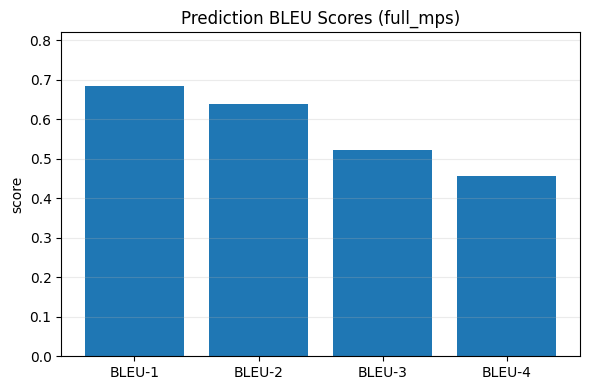

(PosixPath('/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/figures/t5_full_mps_bleu.png'),
 PosixPath('/Users/yunye/Documents/课程/大三下/机器学习基础/大作业/t5_qa_project/outputs/t5_full_mps/experiment_summary.json'))

In [12]:
bleu_keys = ["bleu_1", "bleu_2", "bleu_3", "bleu_4"]
bleu_values = [prediction_scores[key] for key in bleu_keys]

plt.figure(figsize=(6, 4))
plt.bar([key.upper().replace("_", "-") for key in bleu_keys], bleu_values)
plt.ylim(0, max(0.1, max(bleu_values) * 1.2))
plt.ylabel("score")
plt.title("Prediction BLEU Scores (full_mps)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
bleu_figure_path = FIGURE_DIR / "t5_full_mps_bleu.png"
plt.savefig(bleu_figure_path, dpi=200)
plt.show()

summary = {
    **config_summary,
    "device": str(training_args.device),
    "estimated_optimizer_steps": math.ceil(len(train_rows) / (TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)) * NUM_TRAIN_EPOCHS,
    "train_metrics": train_metrics,
    "eval_metrics": eval_metrics,
    "prediction_sample_bleu": prediction_scores,
    "prediction_sample_size": len(prediction_rows),
}
summary_path = OUTPUT_DIR / "experiment_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

bleu_figure_path, summary_path